# P5 — Generative Model: Half-Hourly GB Generation

A single probabilistic Transformer that learns, from the training-split sites only, a distribution over half-hourly generation output conditioned purely on **when in the year** a half-hour falls and **what site** it belongs to (location, fuel type, rough scale) — no real time-series history is fed as model input, only as the training target.

**Task ownership**: this notebook builds the model and reports training diagnostics (Tasks 1-3). It stops before generation/evaluation (Task 4) for Simon to review the loss curve first. `Generative_AI_Analysis_Report.pdf` is Simon's document, not built here.

## Task 1 — Generative task statement, architecture rationale, misuse framing

### What this model does

Given a **site's metadata** (its location, fuel type, and a rough capacity scale) and **a position in the calendar year**, produce a probability distribution over that half-hour's generation output. Sampling from that distribution repeatedly, for every half-hour across a full year, produces one synthetic generation trace for that site. Sampling many times produces an ensemble — a spread of plausible traces, not one "best guess."

This is deliberately **not** a forecasting model. It has no access to weather, no access to a site's recent real output, and no causal/autoregressive structure that would let it condition on "what just happened." It only knows *where and what kind of site this is* and *what time of year it is*. That's a feature, not an oversight — see the misuse framing below.

### Architecture choice: a plain probabilistic Transformer, not a CVAE or hurdle model

**Locked for this build**: a single Transformer encoder with bidirectional self-attention (no causal masking) over a 1,440-step (30-day, half-hourly) chunk, outputting a per-position Gaussian (μ, σ), trained with Gaussian negative log-likelihood against the real chunk.

Simplicity is chosen deliberately over the more expressive alternatives documented (not built) below. The reasoning: a working, well-understood baseline should exist before adding the complexity of a latent-variable model or a mixture-type output head — if the plain model's loss curve and generated ensembles turn out inadequate in a specific, identifiable way, that failure mode should point directly at which piece of added complexity would actually fix it, rather than guessing upfront.

### Misuse framing: simulation, not prediction

This model generates **statistically plausible synthetic scenarios**, conditioned on site metadata and calendar position — it does not predict real generation at a real future time for a real site. Concretely, it must not be used for:

- **Forecasting or trading decisions** — it has no access to weather, plant status, or recent real output, so it cannot know whether a specific real half-hour will be windy, an outage, or a maintenance window.
- **Claims about a specific site's actual future behaviour** — generated traces are draws from a learned population-level distribution conditioned on coarse metadata (location, fuel type, rough scale), not a site-specific forecast.
- **Representing generated output as measured data** — anywhere a generated trace is used (analysis, testing, augmentation), it should be clearly labelled as synthetic.

Legitimate uses sit on the "simulation" side of that line: stress-testing downstream analysis code against plausible-but-varied inputs, exploring how a hypothetical new site's output might vary given only its metadata, or generating synthetic training data for another model that needs more spatial coverage than the real fleet provides.

### Documented, not built — one line each, with reasoning

- **CVAE latent structure**: a latent scenario variable (e.g. "a windy year" vs "a calm year") would let generated ensembles vary coherently across a whole chunk rather than only through independent per-position sampling — deferred unless the plain model's ensemble diversity proves too narrow or too incoherent once actually generated and inspected.
- **Hurdle output head**: a two-part (zero-probability + continuous-given-nonzero) output would directly address the zero-inflation the EDA notebooks found in OCGT and COAL (near-100% and ~87% near-zero respectively) — deferred to first see whether a plain Gaussian, misspecified as it is for a spiky bimodal series, still produces a usable ensemble for those fuel types once trained, or whether it visibly fails only there.
- **Explicit noise injection at generation time**: correlated (rather than fully independent per-position) sampling noise could restore some of the short-term autocorrelation real half-hourly data has and this architecture's independent-per-position sampling cannot reproduce — deferred as a post-hoc generation-time enhancement, worth considering only if generated traces look implausibly jittery compared to real data once actually generated.

## Task 2 — Data pipeline: load, chunk, inspect

**Train-split sites only** — cross-checked against `site_split_assignment.csv`, same discipline as `granularity_eda.ipynb`. Val and test sites are never loaded here.

**Chunking**: each site's history is split into fixed, non-overlapping 1,440-step (30-day) windows aligned to a simplified **360-day year** — calendar day-of-year 1-30 is chunk 0, 31-60 is chunk 1, ..., 331-360 is chunk 11, and the trailing ~5-6 days of each real year are dropped. This means the same chunk index always corresponds to the same time of year regardless of which real year it came from, which is what lets a single shared model learn a general seasonal pattern from multiple years of one site's history (most training sites have 6-7 years spanning 2019-2026). A chunk is only kept if all 1,440 half-hourly periods are actually present — no gap-filling.

**Position-in-year encoding**: for a half-hour with real calendar `day_of_year` (1-360) and `settlementPeriod` (1-48), `position_in_year = (day_of_year - 1) * 48 + (settlementPeriod - 1)`, ranging 0-17,279 across the 12 chunks. This absolute position (not just position-within-chunk) is what the sinusoidal encoding is built on, so the model can tell chunk 0 of one year from chunk 0 of another apart from chunk 6 (mid-year) — all instances of "day 1-30" share the same position range, all instances of "day 181-210" share a different one.

**Normalisation**: each site's target values are divided by that site's own observed maximum absolute output (`site_max_abs`) — the same proxy-capacity convention established in the EDA notebooks. This puts every site on a roughly comparable 0-1-ish scale despite the huge real-MW range across fuel types (small hydro ~tens of MW vs nuclear ~1,000 MW), which matters for a single shared-weights model trained across all of them. The site's own `log1p(site_max_abs)` is then fed back in as an explicit conditioning input, so the model isn't blind to scale — just trained on a normalised target.

In [1]:
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

INTERIM_DIR = Path("../data/interim")
REF_DIR = Path("../data/reference")
MODELS_DIR = Path("../models")

FUEL_COLOURS = {
    "WIND": "#2a78d6", "CCGT": "#eb6834", "NPSHYD": "#1baf7a", "NUCLEAR": "#eda100",
    "OCGT": "#e87ba4", "COAL": "#008300", "BIOMASS": "#4a3aa7",
    "PS": "#e34948", "RECIPROCATING": "#9085e9",
}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))

torch 2.13.0+cu130, device: cuda (NVIDIA GB10)


In [2]:
# Authoritative split source, cross-checked against the parquet's own split column
split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")
train_keys = set(
    zip(split_assignment.loc[split_assignment["split"] == "train", "dictionary_id"],
        split_assignment.loc[split_assignment["split"] == "train", "fuel_type"])
)

raw = pd.read_parquet(INTERIM_DIR / "site_generation_consolidated.parquet")
df = raw.loc[raw["split"] == "train"].copy()
del raw

parquet_train_keys = set(zip(df["dictionary_id"], df["fuel_type"]))
assert parquet_train_keys == train_keys, "parquet split column disagrees with site_split_assignment.csv"

df["settlementDate"] = pd.to_datetime(df["settlementDate"])
df["day_of_year"] = df["settlementDate"].dt.dayofyear
df["year"] = df["settlementDate"].dt.year
df = df[df["day_of_year"] <= 360].copy()  # simplified 360-day year, see Task 2 intro
df["position_in_year"] = (df["day_of_year"] - 1) * 48 + (df["settlementPeriod"] - 1)
df["chunk_index"] = df["position_in_year"] // 1440
df["position_in_chunk"] = df["position_in_year"] % 1440

print(f"Train-only rows: {len(df):,} across {df['site_fuel_id'].nunique()} fuel-series")
print(df.groupby("fuel_type")["site_fuel_id"].nunique())

Train-only rows: 17,379,445 across 140 fuel-series


fuel_type
BIOMASS           3
CCGT             26
COAL              4
NPSHYD            9
NUCLEAR           4
OCGT              7
PS                4
RECIPROCATING     3
WIND             80
Name: site_fuel_id, dtype: int64


In [3]:
# Per-site metadata: observed max (normalisation scale + capacity proxy), coordinates, fuel type
site_max = df.groupby("site_fuel_id")["quantity"].apply(lambda s: s.abs().max())
fuel_types = sorted(df["fuel_type"].unique())
fuel_to_idx = {ft: i for i, ft in enumerate(fuel_types)}

site_meta = df.groupby("site_fuel_id").agg(
    longitude=("longitude", "first"), latitude=("latitude", "first"), fuel_type=("fuel_type", "first")
)
site_meta["site_max_abs"] = site_max
site_meta["log_capacity"] = np.log1p(site_meta["site_max_abs"])
site_meta["fuel_idx"] = site_meta["fuel_type"].map(fuel_to_idx)

# Coordinates standardised across the training fleet - keeps the metadata projection's
# input scales comparable to the log-capacity and embedding dimensions
LON_MEAN, LON_STD = site_meta["longitude"].mean(), site_meta["longitude"].std()
LAT_MEAN, LAT_STD = site_meta["latitude"].mean(), site_meta["latitude"].std()
site_meta["lon_std"] = (site_meta["longitude"] - LON_MEAN) / LON_STD
site_meta["lat_std"] = (site_meta["latitude"] - LAT_MEAN) / LAT_STD

print(f"{len(fuel_types)} fuel types in the training set: {fuel_types}")
site_meta.head()

9 fuel types in the training set: ['BIOMASS', 'CCGT', 'COAL', 'NPSHYD', 'NUCLEAR', 'OCGT', 'PS', 'RECIPROCATING', 'WIND']


,longitude,latitude,fuel_type,site_max_abs,log_capacity,fuel_idx,lon_std,lat_std
site_fuel_id,,,,,,,,
10000_BIOMASS,-3.603516,57.480403,BIOMASS,41.064,3.739192,0,-0.423575,1.167209
10001_CCGT,-1.267570,51.623630,CCGT,736.500,6.603266,1,0.720357,-1.377947
10001_OCGT,-1.267570,51.623630,OCGT,50.429,3.940202,5,0.720357,-1.377947
10004_BIOMASS,-0.996631,53.736634,BIOMASS,1299.870,7.170789,0,0.853038,-0.459707
10004_COAL,-0.996631,53.736634,COAL,645.302,6.471267,2,0.853038,-0.459707


In [4]:
def build_chunks(df, site_meta):
    chunks = []
    for (site_fuel_id, year, chunk_idx), g in df.groupby(["site_fuel_id", "year", "chunk_index"]):
        if len(g) != 1440:
            continue
        g = g.sort_values("position_in_chunk")
        if not (g["position_in_chunk"].to_numpy() == np.arange(1440)).all():
            continue  # gaps within an otherwise 1440-row chunk - skip rather than guess
        meta = site_meta.loc[site_fuel_id]
        if meta["site_max_abs"] == 0:
            continue
        values = (g["quantity"].to_numpy() / meta["site_max_abs"]).astype(np.float32)
        chunks.append({
            "site_fuel_id": site_fuel_id, "fuel_type": meta["fuel_type"],
            "year": year, "chunk_index": int(chunk_idx),
            "values": values,
            "lon_std": meta["lon_std"], "lat_std": meta["lat_std"],
            "log_capacity": meta["log_capacity"], "fuel_idx": meta["fuel_idx"],
        })
    return chunks


t0 = time.time()
chunks = build_chunks(df, site_meta)
print(f"Built {len(chunks)} complete 30-day chunks in {time.time()-t0:.1f}s")

chunk_summary = pd.DataFrame([{"fuel_type": c["fuel_type"], "site_fuel_id": c["site_fuel_id"]} for c in chunks])
print(chunk_summary.groupby("fuel_type").size().sort_values(ascending=False))

Built 9807 complete 30-day chunks in 2.6s
fuel_type
WIND             5671
CCGT             1843
NPSHYD            657
OCGT              439
PS                292
NUCLEAR           247
COAL              220
BIOMASS           219
RECIPROCATING     219
dtype: int64


### Representative chunks across fuel types

One chunk (30 days, half-hourly, normalised to fraction of that site's own observed max) per fuel type, picked from a site with a long clean record — a direct visual sanity check that the chunking and normalisation logic actually produced sensible input before any of it goes near a model.

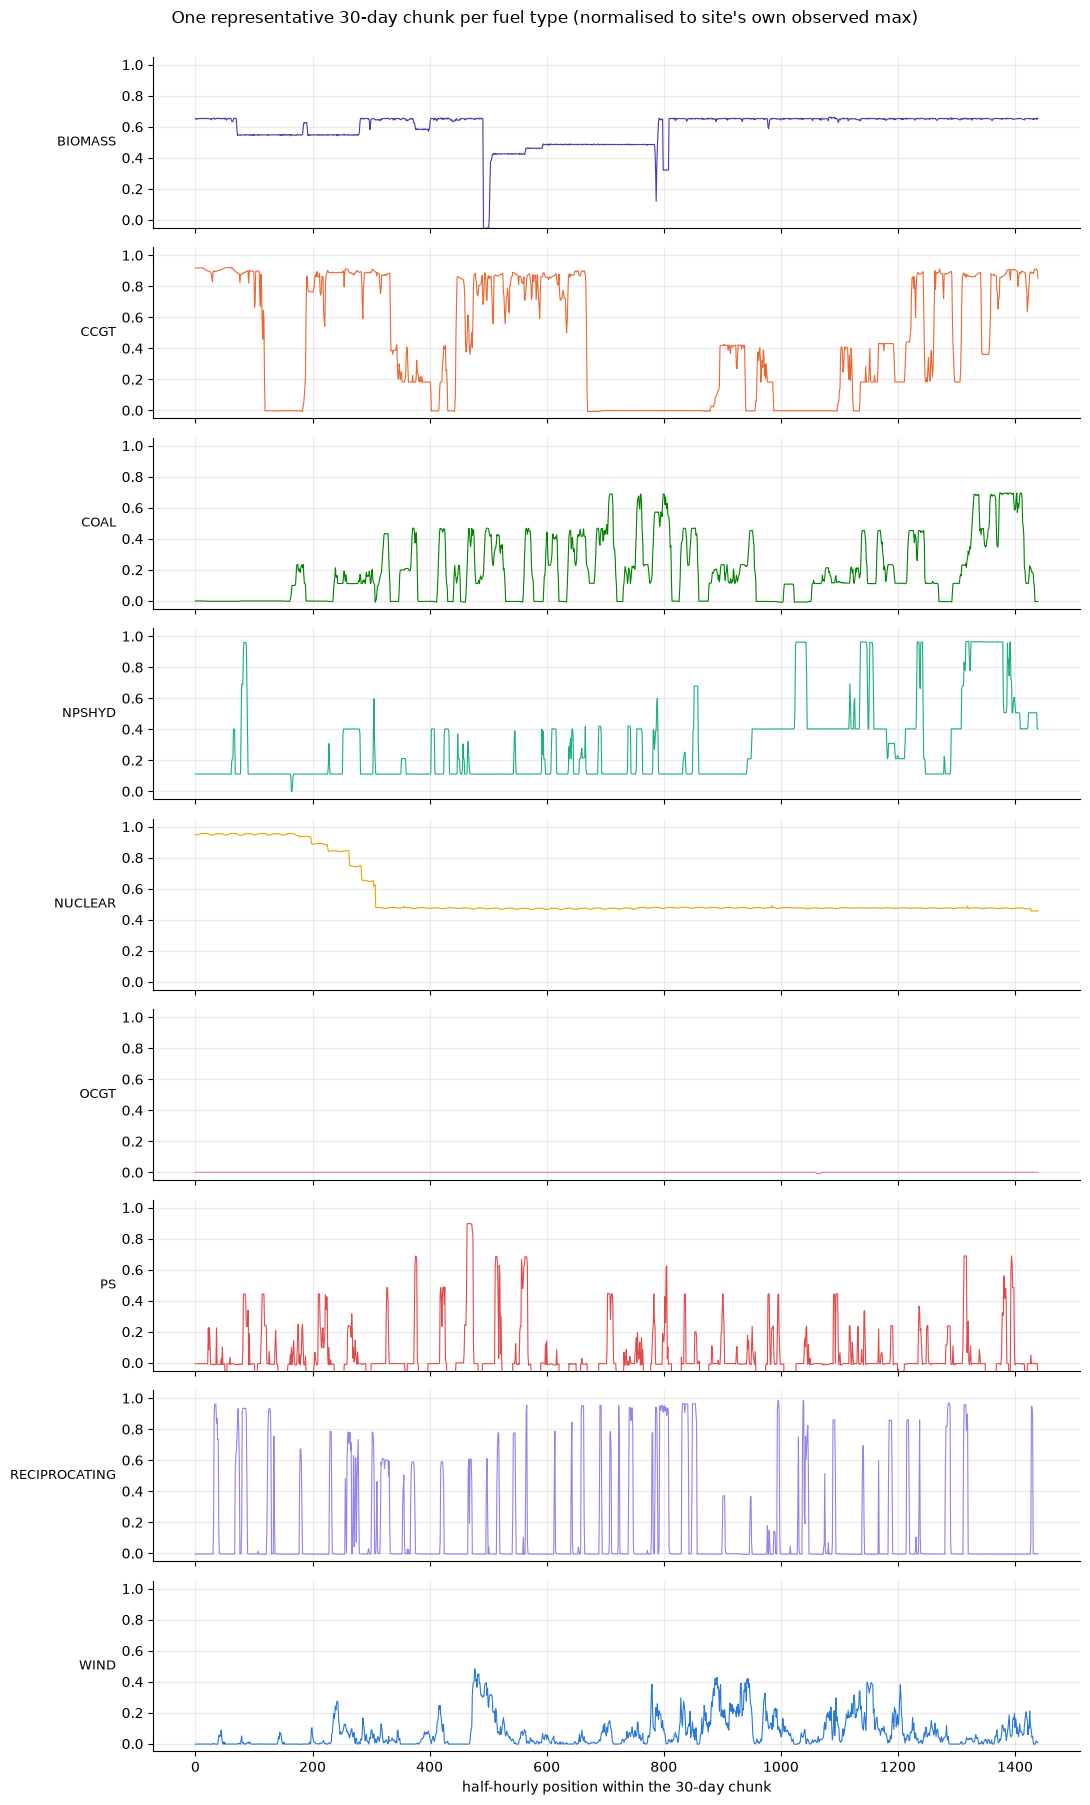

In [5]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(len(fuel_types), 1, figsize=(11, 2 * len(fuel_types)), sharex=True)

for ax, ft in zip(axes, fuel_types):
    ft_chunks = [c for c in chunks if c["fuel_type"] == ft]
    chosen = ft_chunks[rng.integers(len(ft_chunks))]
    ax.plot(chosen["values"], color=FUEL_COLOURS.get(ft, "#52514e"), linewidth=0.8)
    ax.set_ylabel(ft, rotation=0, ha="right", va="center", fontsize=9)
    ax.set_ylim(-0.05, 1.05)

axes[-1].set_xlabel("half-hourly position within the 30-day chunk")
fig.suptitle("One representative 30-day chunk per fuel type (normalised to site's own observed max)", y=1.0)
plt.tight_layout()
plt.show()

### Known mismatch: Gaussian loss vs zero-inflated fuel types

`granularity_eda.ipynb` and `dead_site_sweep.ipynb` both establish that several fuel types are heavily zero-inflated at half-hourly resolution — OCGT sits at ≈99.8% near-zero periods, COAL ≈87%, both with a sharp bimodal "off, or near-full" shape rather than anything resembling a smooth continuous distribution. A Gaussian likelihood is a poor description of that shape: it can only represent a single unimodal bump, so for these fuel types it will end up predicting something like "usually near zero, with a wide-ish spread to account for the occasional spike" rather than genuinely capturing "almost always exactly zero, rarely at full output." WIND, NPSHYD and CCGT are less extreme but still meaningfully zero-inflated; NUCLEAR and BIOMASS are the closest to a Gaussian's implicit assumption of a single central tendency with symmetric spread.

This is a **known, accepted limitation of the locked architecture for this build**, not something patched around here — it's exactly the gap the hurdle output head (documented, not built, in Task 1) would close. Worth watching for in the loss curve (a persistently high loss floor for OCGT/COAL-heavy batches would be the expected symptom) and worth stating plainly if it shows up in the eventual report, not glossed over.

## Task 3 — Model, training loop, loss curve

**Architecture, as locked**:
- Sinusoidal positional encoding over the full 17,280-position year, indexed by each half-hour's absolute position (not just position within the 1,440-step chunk) — so the same encoding value always means the same time of year.
- Site conditioning — standardised longitude/latitude, a fuel-type embedding, and log-scaled observed-max capacity — projected to the same width as the positional encoding and **added** to it, identically at every position in the chunk (the model has no other way to know which site or time period it's looking at; nothing about the real values is fed in as input, only used as the training target).
- A standard Transformer encoder stack, bidirectional self-attention, no causal mask — every position can attend to every other position in the chunk, forwards and backwards.
- A linear output head per position producing (μ, raw), with σ = softplus(raw) + a small floor, trained against the real normalised value at that position with Gaussian negative log-likelihood.

**Checkpointing, resumability, no `tmux`**: every epoch's model/optimiser state, RNG state, and loss history are written to `models/generative_model/checkpoint.pt`, plus a lightweight `training_log.csv` row (cheap to read without touching the full checkpoint). On startup, this notebook loads whatever checkpoint already exists and resumes from the next epoch — safe to interrupt and re-run from scratch at any point, deliberately not relying on any process surviving outside this session.

In [6]:
CHUNK_LEN = 1440
N_YEAR_POSITIONS = 17280

class ChunkDataset(Dataset):
    def __init__(self, chunk_list):
        self.chunks = chunk_list

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        c = self.chunks[idx]
        start = c["chunk_index"] * CHUNK_LEN
        positions = np.arange(start, start + CHUNK_LEN, dtype=np.int64)
        return {
            "positions": positions,
            "values": c["values"],
            "lon_std": np.float32(c["lon_std"]),
            "lat_std": np.float32(c["lat_std"]),
            "log_capacity": np.float32(c["log_capacity"]),
            "fuel_idx": np.int64(c["fuel_idx"]),
        }


def collate(batch):
    return {
        "positions": torch.from_numpy(np.stack([b["positions"] for b in batch])),
        "values": torch.from_numpy(np.stack([b["values"] for b in batch])),
        "lon_std": torch.tensor([b["lon_std"] for b in batch]),
        "lat_std": torch.tensor([b["lat_std"] for b in batch]),
        "log_capacity": torch.tensor([b["log_capacity"] for b in batch]),
        "fuel_idx": torch.tensor([b["fuel_idx"] for b in batch]),
    }


# Chunk-level 90/10 holdout purely for training diagnostics (over/underfitting) -
# distinct from, and orthogonal to, the site-level train/val/test split. These
# "val" chunks still come from train-split SITES only; nothing from the reserved
# val/test sites is anywhere in this notebook.
CHUNK_SPLIT_SEED = 42
rng = np.random.default_rng(CHUNK_SPLIT_SEED)
shuffled_idx = rng.permutation(len(chunks))
n_holdout = int(0.1 * len(chunks))
holdout_idx = set(shuffled_idx[:n_holdout].tolist())

train_chunks = [c for i, c in enumerate(chunks) if i not in holdout_idx]
val_chunks = [c for i, c in enumerate(chunks) if i in holdout_idx]
print(f"{len(train_chunks)} training chunks, {len(val_chunks)} chunk-level holdout chunks (for loss monitoring only)")

BATCH_SIZE = 128
train_loader = DataLoader(ChunkDataset(train_chunks), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(ChunkDataset(val_chunks), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

8827 training chunks, 980 chunk-level holdout chunks (for loss monitoring only)


In [7]:
class SinusoidalPositionalEncoding(nn.Module):
    """Standard Vaswani-style encoding, indexed by absolute position in the 360-day year."""
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, position_indices):
        return self.pe[position_indices]


class GenerativeTransformer(nn.Module):
    """Bidirectional Transformer encoder over a 1440-step chunk. Every position gets
    the same site-conditioning vector added to its positional encoding - no real
    values are ever part of the input, only the training target."""

    def __init__(self, d_model, nhead, num_layers, dim_feedforward, n_fuel_types, dropout=0.1):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, N_YEAR_POSITIONS)
        self.fuel_emb = nn.Embedding(n_fuel_types, d_model)
        self.meta_proj = nn.Linear(3, d_model)  # lon_std, lat_std, log_capacity
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, dropout, activation="gelu", batch_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers)
        self.head = nn.Linear(d_model, 2)

    def forward(self, positions, lon_std, lat_std, log_capacity, fuel_idx):
        pos = self.pos_enc(positions)  # (B, L, D)
        meta = self.fuel_emb(fuel_idx) + self.meta_proj(
            torch.stack([lon_std, lat_std, log_capacity], dim=-1)
        )  # (B, D)
        x = pos + meta.unsqueeze(1)  # broadcast identically to every position
        x = self.encoder(x)  # bidirectional, no mask passed - full self-attention
        out = self.head(x)
        mu, raw_sigma = out[..., 0], out[..., 1]
        sigma = torch.nn.functional.softplus(raw_sigma) + 1e-3
        return mu, sigma


MODEL_CONFIG = dict(d_model=128, nhead=4, num_layers=4, dim_feedforward=256, n_fuel_types=len(fuel_types), dropout=0.1)
model = GenerativeTransformer(**MODEL_CONFIG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"GenerativeTransformer: {n_params:,} parameters")
print(MODEL_CONFIG)

GenerativeTransformer: 531,842 parameters
{'d_model': 128, 'nhead': 4, 'num_layers': 4, 'dim_feedforward': 256, 'n_fuel_types': 9, 'dropout': 0.1}


### Checkpointed training loop

Saves after every epoch: model/optimiser state, epoch number, full loss history, and the model config (so a resumed run can rebuild an identical model before loading the weights into it). A separate `training_log.csv` gets one row per epoch too — cheap to read for monitoring progress without touching the multi-hundred-MB checkpoint file.

Resuming is just re-running this cell: if a checkpoint exists on disk, training picks up at `epoch + 1` with the exact optimiser state it left off with, rather than starting cold. Interrupting this (window drop, manual stop, anything) loses at most the current in-progress epoch, never more.

In [ ]:
CHECKPOINT_DIR = MODELS_DIR / "generative_model"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "checkpoint.pt"          # latest epoch, for resuming
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_checkpoint.pt"  # best chunk-level holdout loss so far
LOG_PATH = CHECKPOINT_DIR / "training_log.csv"

TOTAL_EPOCHS = 300
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4  # added after run 1 (below) showed clear overfitting past ~epoch 175
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 30  # stop if holdout loss hasn't improved in this many epochs

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.GaussianNLLLoss(full=True)


def save_checkpoint(epoch, train_history, val_history, best_val_loss, epochs_since_improvement):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "train_loss_history": train_history,
        "val_loss_history": val_history,
        "best_val_loss": best_val_loss,
        "epochs_since_improvement": epochs_since_improvement,
        "model_config": MODEL_CONFIG,
        "fuel_to_idx": fuel_to_idx,
    }, CHECKPOINT_PATH)


def save_best_checkpoint(epoch, val_loss):
    torch.save({
        "epoch": epoch,
        "val_loss": val_loss,
        "model_state": model.state_dict(),
        "model_config": MODEL_CONFIG,
        "fuel_to_idx": fuel_to_idx,
    }, BEST_CHECKPOINT_PATH)


def load_checkpoint_if_exists():
    if not CHECKPOINT_PATH.exists():
        return 0, [], [], float("inf"), 0
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    assert ckpt["model_config"] == MODEL_CONFIG, "checkpoint was trained with a different model config"
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    print(f"Resumed from checkpoint at epoch {ckpt['epoch']}")
    return (
        ckpt["epoch"] + 1, ckpt["train_loss_history"], ckpt["val_loss_history"],
        ckpt.get("best_val_loss", float("inf")), ckpt.get("epochs_since_improvement", 0),
    )


def run_epoch(loader, train: bool):
    model.train(train)
    total_loss, n_positions = 0.0, 0
    with torch.set_grad_enabled(train):
        for batch in loader:
            positions = batch["positions"].to(DEVICE)
            values = batch["values"].to(DEVICE)
            lon_std = batch["lon_std"].to(DEVICE)
            lat_std = batch["lat_std"].to(DEVICE)
            log_capacity = batch["log_capacity"].to(DEVICE)
            fuel_idx = batch["fuel_idx"].to(DEVICE)

            mu, sigma = model(positions, lon_std, lat_std, log_capacity, fuel_idx)
            loss = loss_fn(mu, values, sigma ** 2)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()

            total_loss += loss.item() * values.numel()
            n_positions += values.numel()
    return total_loss / n_positions

In [ ]:
start_epoch, train_loss_history, val_loss_history, best_val_loss, epochs_since_improvement = load_checkpoint_if_exists()

if not LOG_PATH.exists():
    with open(LOG_PATH, "w") as f:
        f.write("epoch,train_loss,val_loss,epoch_seconds,timestamp\n")

print(f"Training from epoch {start_epoch} to {TOTAL_EPOCHS - 1} ({TOTAL_EPOCHS - start_epoch} epochs to run), "
      f"early stopping patience={EARLY_STOPPING_PATIENCE}")

run_start = time.time()
for epoch in range(start_epoch, TOTAL_EPOCHS):
    t0 = time.time()
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    epoch_seconds = time.time() - t0

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_since_improvement = 0
        save_best_checkpoint(epoch, val_loss)
    else:
        epochs_since_improvement += 1

    save_checkpoint(epoch, train_loss_history, val_loss_history, best_val_loss, epochs_since_improvement)

    with open(LOG_PATH, "a") as f:
        f.write(f"{epoch},{train_loss:.6f},{val_loss:.6f},{epoch_seconds:.1f},{pd.Timestamp.now().isoformat(timespec='seconds')}\n")

    if epoch % 5 == 0 or epoch == TOTAL_EPOCHS - 1:
        eta_s = epoch_seconds * (TOTAL_EPOCHS - epoch - 1)
        print(f"[epoch {epoch:3d}/{TOTAL_EPOCHS-1}] train={train_loss:.4f} val={val_loss:.4f} "
              f"(best={best_val_loss:.4f} @ epoch {epoch - epochs_since_improvement}, "
              f"{epoch_seconds:.1f}s/epoch, ETA ~{eta_s/60:.1f} min)")

    if epochs_since_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping: no holdout improvement in {EARLY_STOPPING_PATIENCE} epochs "
              f"(best={best_val_loss:.4f} at epoch {epoch - epochs_since_improvement}). Stopping at epoch {epoch}.")
        break

print(f"\nDone. {len(train_loss_history)} total epochs in history, this run took {(time.time()-run_start)/60:.1f} min.")
print(f"Best holdout loss: {best_val_loss:.4f} (checkpoint saved separately at {BEST_CHECKPOINT_PATH})")

### Loss curve

Gaussian NLL, train vs the chunk-level holdout, across every completed epoch. This is the diagnostic Simon reviews before Task 4 (generation/evaluation) begins — nothing past this point runs without that review.

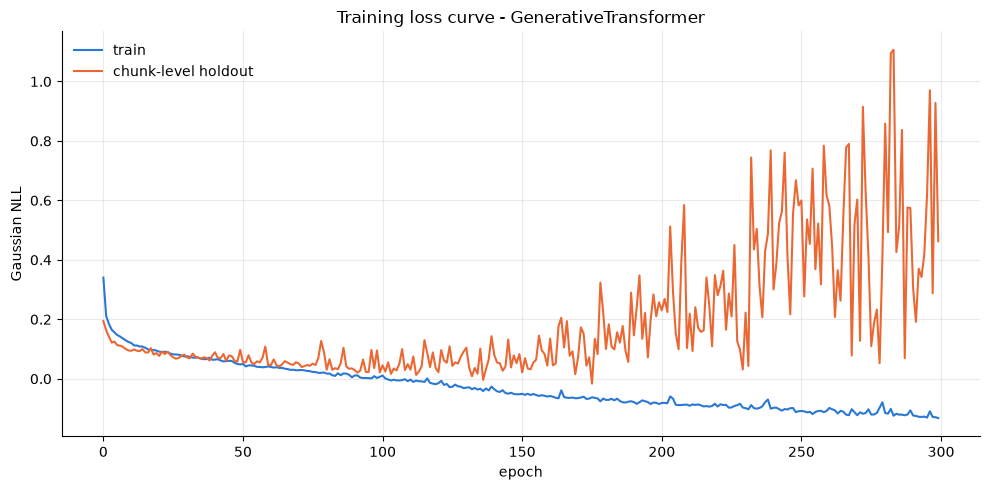

Final train loss: -0.1322
Final holdout loss: 0.4630
Best holdout loss: -0.0163 (epoch 175)


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
epochs_axis = range(len(train_loss_history))
ax.plot(epochs_axis, train_loss_history, color="#2a78d6", label="train", linewidth=1.5)
ax.plot(epochs_axis, val_loss_history, color="#eb6834", label="chunk-level holdout", linewidth=1.5)
ax.set_xlabel("epoch")
ax.set_ylabel("Gaussian NLL")
ax.set_title("Training loss curve - GenerativeTransformer")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Final train loss: {train_loss_history[-1]:.4f}")
print(f"Final holdout loss: {val_loss_history[-1]:.4f}")
print(f"Best holdout loss: {min(val_loss_history):.4f} (epoch {val_loss_history.index(min(val_loss_history))})")

### Run 1 diagnostics: clear overfitting past ~epoch 175

Full 300-epoch run, completed. **Not a clean result** — worth stating plainly rather than glossing over:

- Train loss decreases smoothly and monotonically the entire way, ending negative (-0.13 at epoch 299) — a Gaussian NLL can go negative once the model's predicted σ shrinks below a certain point, and that's exactly what's happening: the model keeps getting more *confident*, not necessarily more *correct*.
- Holdout (chunk-level) loss improves alongside it only up to **epoch 175** (best holdout loss -0.016), then becomes increasingly volatile and trends upward — by epoch 250-290 it's swinging between 0.3 and 0.97+, far worse than where it started.
- The mechanism is coherent: as training continues past the useful point, predicted σ keeps shrinking (that's what drives train loss negative), which makes NLL increasingly punishing for any held-out chunk the shrunk-σ prediction doesn't match well — a classic overconfidence failure mode, not just "the mean prediction got worse."

**Consequence discovered along the way**: the training loop as first written only checkpointed the *latest* epoch, not the *best* one — so epoch 175's actual weights no longer exist, only epoch 299's (the overfit ones) do. Fixed in the training loop above (separate best-checkpoint tracking + early stopping with a 30-epoch patience, plus a small weight-decay addition), but that fix arrived after this run finished, so this run's results are a diagnostic, not a usable model.

This run's checkpoint and log are preserved at `models/generative_model_run1_baseline/` (not deleted, not overwritten) precisely because the overfitting pattern itself is useful evidence, even though the final weights aren't what should be used.

## Stopping point (updated)

**Run 1 (300 epochs, fixed budget) is done and is a genuine diagnostic result, not a usable model** — see the overfitting note above. Best holdout loss was at epoch 175; the training loop only kept the latest checkpoint at the time, so those weights aren't recoverable. Preserved as-is at `models/generative_model_run1_baseline/` rather than deleted or overwritten.

**The training loop above has since been fixed** (best-checkpoint tracking, early stopping at 30 epochs' patience, a small weight-decay addition) but **run 2 hasn't happened yet** — the session window available when this fix went in was too short to safely start another multi-hour run. `models/generative_model/` is now empty and ready for a clean run.

### To resume: run 2, in `tmux` this time

This one specifically should go in `tmux` (not the usual session-tied background execution) since it needs to outlive a single short window:

```bash
cd "/home/simon/AI Masters/Capstone Projects/generative-ai-elexon"
tmux new -s genmodel
# inside the tmux session:
.venv/bin/jupyter nbconvert --to notebook --execute --inplace notebooks/generative_model.ipynb --ExecutePreprocessor.timeout=20000
# detach once it's running: Ctrl+B, then D
```

**To check progress later** (from any shell, doesn't need the tmux session attached):
```bash
tail -20 "/home/simon/AI Masters/Capstone Projects/generative-ai-elexon/models/generative_model/training_log.csv"
```

**To reattach and see it running live**: `tmux attach -t genmodel`

**What to expect**: early stopping (30-epoch patience) means this shouldn't run the full 300 epochs again — based on run 1's pattern (best around epoch 175), expect it to stop somewhere around epoch 200-210, roughly **~2.5-3 hours** at the ~51s/epoch this model trains at on the GB10. It's checkpointed every epoch exactly as before, so even this run is safe to interrupt and resume (just re-run the same command — it'll pick up from the last completed epoch, same as run 1's smoke test proved out).

**Per the brief, still true**: this notebook stops here regardless — Task 4 (generation and evaluation) doesn't begin until Simon has reviewed the loss curve, whichever run that ends up being.